# Fit two data groups

Fit a zero-inflated gamma regression with separate variational blocks and optimizers. The zero branch uses all binary indicators; the Gamma branch uses only positive responses. Their different sample sizes require separate splits and batches.

## Imports

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

In [2]:
pd.options.display.float_format = "{:.3f}".format

## Simulate data

Simulate 1,000 observations. A zero indicator of one selects the structural-zero component; the remaining observations form the positive branch.

In [3]:
rng = np.random.default_rng(202406)

n_zero = 1000
x_zero = rng.normal(size=n_zero)
risk_score = rng.uniform(-1.0, 1.0, size=n_zero)
X_zero = np.column_stack([np.ones(n_zero), x_zero, risk_score])

alpha_zero_true = np.array([-0.55, 1.10, -0.80])
zero_logits = X_zero @ alpha_zero_true
zero_prob = 1.0 / (1.0 + np.exp(-zero_logits))
zero_count = rng.binomial(1, zero_prob)

positive_mask = zero_count == 0
X_pos = X_zero[positive_mask]
n_positive = X_pos.shape[0]

beta_pos_true = np.array([1.0, 0.65, -0.35])
concentration_true = 5.0
mean_pos = np.exp(X_pos @ beta_pos_true)
y_pos = rng.gamma(
    shape=concentration_true,
    scale=mean_pos / concentration_true,
)

In [4]:
pd.Series(
    {
        "n_zero_branch": n_zero,
        "n_positive_branch": n_positive,
        "observed_zero_share": float(zero_count.mean()),
        "positive_response_mean": float(y_pos.mean()),
    },
    name="Value",
).to_frame()

,Value
n_zero_branch,1000.000
n_positive_branch,596.000
observed_zero_share,0.404
positive_response_mean,2.449


In [5]:
plot_rng = np.random.default_rng(1001)
zero_data = pd.DataFrame(
    {
        "x": x_zero,
        "zero": zero_count,
        "jittered": zero_count + plot_rng.normal(scale=0.025, size=n_zero),
    }
)
zero_rates = zero_data.groupby(pd.cut(zero_data["x"], bins=11), observed=True).agg(
    x=("x", "mean"), rate=("zero", "mean")
)
zero_plot = (
    p9.ggplot(zero_data, p9.aes("x", "jittered"))
    + p9.geom_point(alpha=0.18, size=1)
    + p9.geom_line(data=zero_rates, mapping=p9.aes(y="rate"))
    + p9.geom_point(data=zero_rates, mapping=p9.aes(y="rate"), size=2)
    + p9.labs(title="Zero component", y="Zero indicator")
)
positive_data = pd.DataFrame({"x": X_pos[:, 1], "response": y_pos})
positive_plot = (
    p9.ggplot(positive_data, p9.aes("x", "response"))
    + p9.geom_point(alpha=0.35, size=1.2)
    + p9.labs(title="Gamma component", y="Positive response")
)

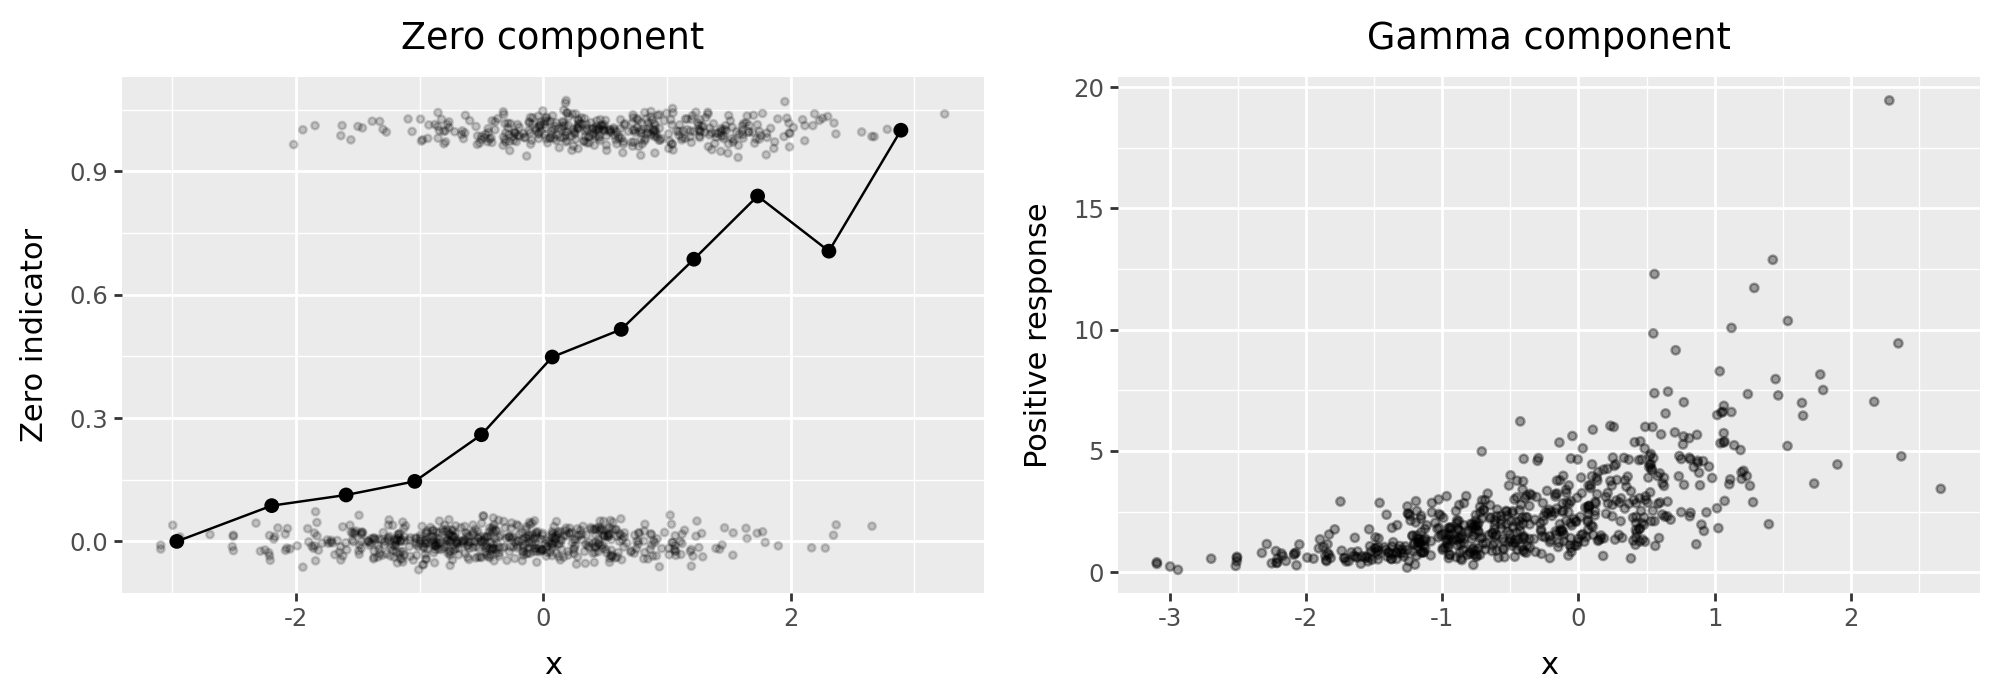

In [6]:
(zero_plot | positive_plot) & p9.theme(figure_size=(10, 3.5))

## Build the branch model

The two likelihood branches share one Liesel model but use separate target parameter blocks. The zero branch owns `alpha_zero`; the positive branch owns `beta_pos` and `log_concentration`.

In [7]:
X_zero_jax = jnp.asarray(X_zero)
zero_count_jax = jnp.asarray(zero_count)
X_pos_jax = jnp.asarray(X_pos)
y_pos_jax = jnp.asarray(y_pos)

# Zero component.
alpha_zero = lsl.Var.new_param(
    jnp.zeros(X_zero_jax.shape[1]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="alpha_zero",
)
X0 = lsl.Var.new_obs(X_zero_jax, name="X_zero")
zero_logit = lsl.Var.new_calc(
    lambda X, alpha: X @ alpha,
    X0,
    alpha_zero,
    name="zero_logit",
)
zero = lsl.Var.new_obs(
    zero_count_jax,
    dist=lsl.Dist(tfd.Binomial, total_count=1.0, logits=zero_logit),
    name="zero_count",
)

# Positive component.
beta_pos = lsl.Var.new_param(
    jnp.zeros(X_pos_jax.shape[1]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta_pos",
)

log_concentration = lsl.Var.new_param(
    jnp.array(0.0),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_concentration",
)
concentration = lsl.Var.new_calc(jnp.exp, log_concentration, name="concentration")

Xp = lsl.Var.new_obs(X_pos_jax, name="X_pos")
eta_pos = lsl.Var.new_calc(
    lambda X, beta: X @ beta,
    Xp,
    beta_pos,
    name="eta_pos",
)
mean_pos_var = lsl.Var.new_calc(jnp.exp, eta_pos, name="mean_pos")

rate_pos = lsl.Var.new_calc(
    lambda concentration, mean: concentration / mean,
    concentration,
    mean_pos_var,
    name="rate_pos",
)

y_positive = lsl.Var.new_obs(
    y_pos_jax,
    dist=lsl.Dist(tfd.Gamma, concentration=concentration, rate=rate_pos),
    name="y_pos",
)

model = lsl.Model([zero, y_positive])

In [8]:
pd.Series(
    {
        "parameters": list(model.parameters),
        "observed": list(model.observed),
    },
    name="Value",
).to_frame()

,Value
parameters,"[beta_pos, log_concentration, alpha_zero]"
observed,"[X_pos, X_zero, zero_count, y_pos]"


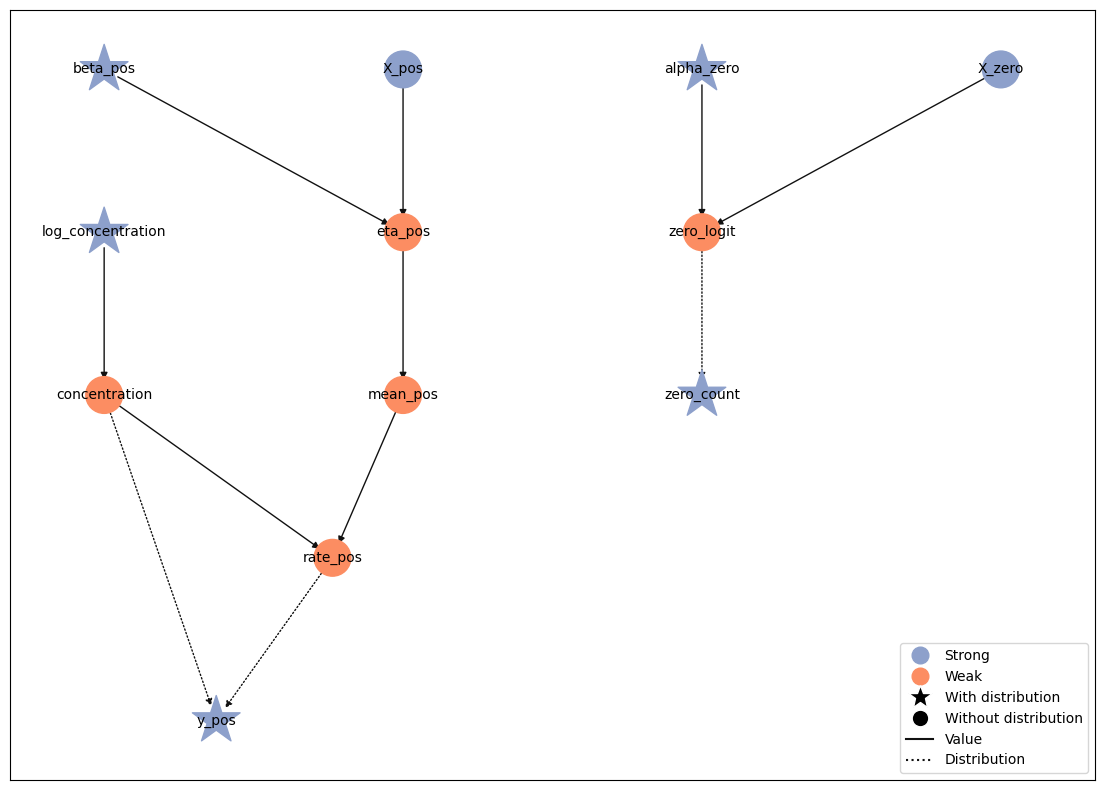

In [9]:
model.plot()

## Split the two branches

Multiple observation sizes require an explicit split. {meth}`PositionSplitManager.from_model() <liesel.optim.PositionSplitManager.from_model>` creates one split per group. Check row alignment within groups and mark shared arrays with `split_axes={key: None}`. For VI, hold out test data only; validation splits are unsupported.

In [10]:
observed_keys = ["X_zero", "zero_count", "X_pos", "y_pos"]

split = opt.PositionSplitManager.from_model(
    model,
    position_keys=observed_keys,
    test_axis_share=0.1,
    shuffle=True,
    seed=123,
)

In [11]:
split

PositionSplitManager(axis_size=(1000, 596), train=(900, 537), validate=(0, 0), test=(100, 59))

In [12]:
pd.DataFrame(
    [
        {
            "keys": ", ".join(child.position_keys),
            "n": child.axis_size,
            "train": child.train_axis_size,
            "validate": child.validate_axis_size,
            "test": child.test_axis_size,
        }
        for child in split.splits
    ]
)

,keys,n,train,validate,test
0,"X_zero, zero_count",1000,900,0,100
1,"X_pos, y_pos",596,537,0,59


## Combine variational blocks

Use a diagonal Gaussian for `alpha_zero` and a dense block for `beta_pos` and `log_concentration`. The dense block can learn correlations within the positive component; {class}`CompositeVDist <liesel.optim.CompositeVDist>` keeps the two blocks independent.

In [13]:
q_zero = opt.VDist(["alpha_zero"], model).mvn_diag(scale_diag=0.2)
q_positive = opt.VDist(
    ["beta_pos", "log_concentration"],
    model,
).mvn_tril(scale_tril=0.2)
vdist = opt.CompositeVDist(q_zero, q_positive).build()

loss = opt.NegElboLoss.from_vdist(
    vdist,
    split,
    nsamples=3,
    scale=True,
)

zero_q_keys = q_zero.parameters
positive_q_keys = q_positive.parameters

In [14]:
pd.DataFrame(
    [
        {"block": "zero", "q_parameters": ", ".join(zero_q_keys)},
        {"block": "positive", "q_parameters": ", ".join(positive_q_keys)},
    ]
)

,block,q_parameters
0,zero,"(alpha_zero)_loc, h((alpha_zero)_scale)"
1,positive,"(beta_pos|log_concentration)_loc, h((beta_pos|..."


## Set block optimizers

Each optimizer selects a disjoint set of **variational** parameter names in `q`, not target parameter names.

In [15]:
zero_schedule = optax.exponential_decay(
    init_value=3e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)
positive_schedule = optax.exponential_decay(
    init_value=2.5e-2,
    transition_steps=60,
    decay_rate=0.95,
    end_value=1e-3,
)

zero_optimizer = opt.Optimizer(
    zero_q_keys,
    optax.adam(zero_schedule),
    identifier="zero_vi_adam",
)
positive_optimizer = opt.Optimizer(
    positive_q_keys,
    optax.adam(positive_schedule),
    identifier="positive_vi_adam",
)

schedule_steps = [0, 60, 120, 240, 360]

In [16]:
pd.DataFrame(
    {
        "step": schedule_steps,
        "zero_learning_rate": [
            float(zero_schedule(step))  # ty: ignore[invalid-argument-type]
            for step in schedule_steps
        ],
        "positive_learning_rate": [
            float(positive_schedule(step))  # ty: ignore[invalid-argument-type]
            for step in schedule_steps
        ],
    }
)

,step,zero_learning_rate,positive_learning_rate
0,0,0.030,0.025
1,60,0.028,0.024
2,120,0.027,0.023
3,240,0.024,0.020
4,360,0.022,0.018


## Fit with separate batches

The engine combines mini-batches from both splits into each stochastic ELBO update.

In [17]:
engine = opt.LieselVI(
    model,
    loss_monitor=opt.EmaTrainLossMonitor(effective_window=20.0),
    loss=loss,
    batch_size=128,
    optimizers=[zero_optimizer, positive_optimizer],
    stopper=opt.Stopper(epochs=350, patience=60, rtol=1e-4),
    seed=321,
).build_engine()
engine.show_progress = False

In [18]:
pd.Series(
    {
        "batching": repr(engine.batches),
        "n": engine.batches.axis_size,
        "batch_size": engine.batches.batch_size,
        "n_full_batches": engine.batches.n_full_batches,
        "optimizer_ids": [optimizer.identifier for optimizer in engine.optimizers],
    },
    name="Value",
).to_frame()

,Value
batching,"BatchManager(axis_size=(900, 537), batch_size=..."
n,"(900, 537)"
batch_size,"(128, 128)"
n_full_batches,7
optimizer_ids,"[zero_vi_adam, positive_vi_adam]"


In [19]:
result = engine.fit()

liesel.optim.engine - INFO - Initializing optimization at epoch 0


In [20]:
result

OptimResult(n_epochs=159, min_monitor_epoch=101, monitor_source='train_ema', duration=5.4s)

## Draw posterior samples

Bind the final iterate (the default) and sample both target parameter blocks with shared leading sample axes.

In [21]:
posterior = loss.approximate_joint_posterior(result, at="final").sample(
    2_000, seed=jax.random.key(2026)
)

alpha_samples = np.asarray(posterior["alpha_zero"])
beta_samples = np.asarray(posterior["beta_pos"])
concentration_samples = np.exp(np.asarray(posterior["log_concentration"]))

rows = [
    {
        "parameter": f"alpha_zero[{i}]",
        "mean": float(alpha_samples[:, i].mean()),
        "sd": float(alpha_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(alpha_zero_true)
]
rows += [
    {
        "parameter": f"beta_pos[{i}]",
        "mean": float(beta_samples[:, i].mean()),
        "sd": float(beta_samples[:, i].std()),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_pos_true)
]
rows.append(
    {
        "parameter": "concentration",
        "mean": float(concentration_samples.mean()),
        "sd": float(concentration_samples.std()),
        "truth": float(concentration_true),
    }
)

In [22]:
pd.DataFrame(rows)

,parameter,mean,sd,truth
0,alpha_zero[0],-0.514,0.080,-0.550
1,alpha_zero[1],1.142,0.096,1.100
2,alpha_zero[2],-0.647,0.152,-0.800
3,beta_pos[0],0.982,0.022,1.000
4,beta_pos[1],0.620,0.027,0.650
5,beta_pos[2],-0.329,0.034,-0.350
6,concentration,5.130,0.348,5.000


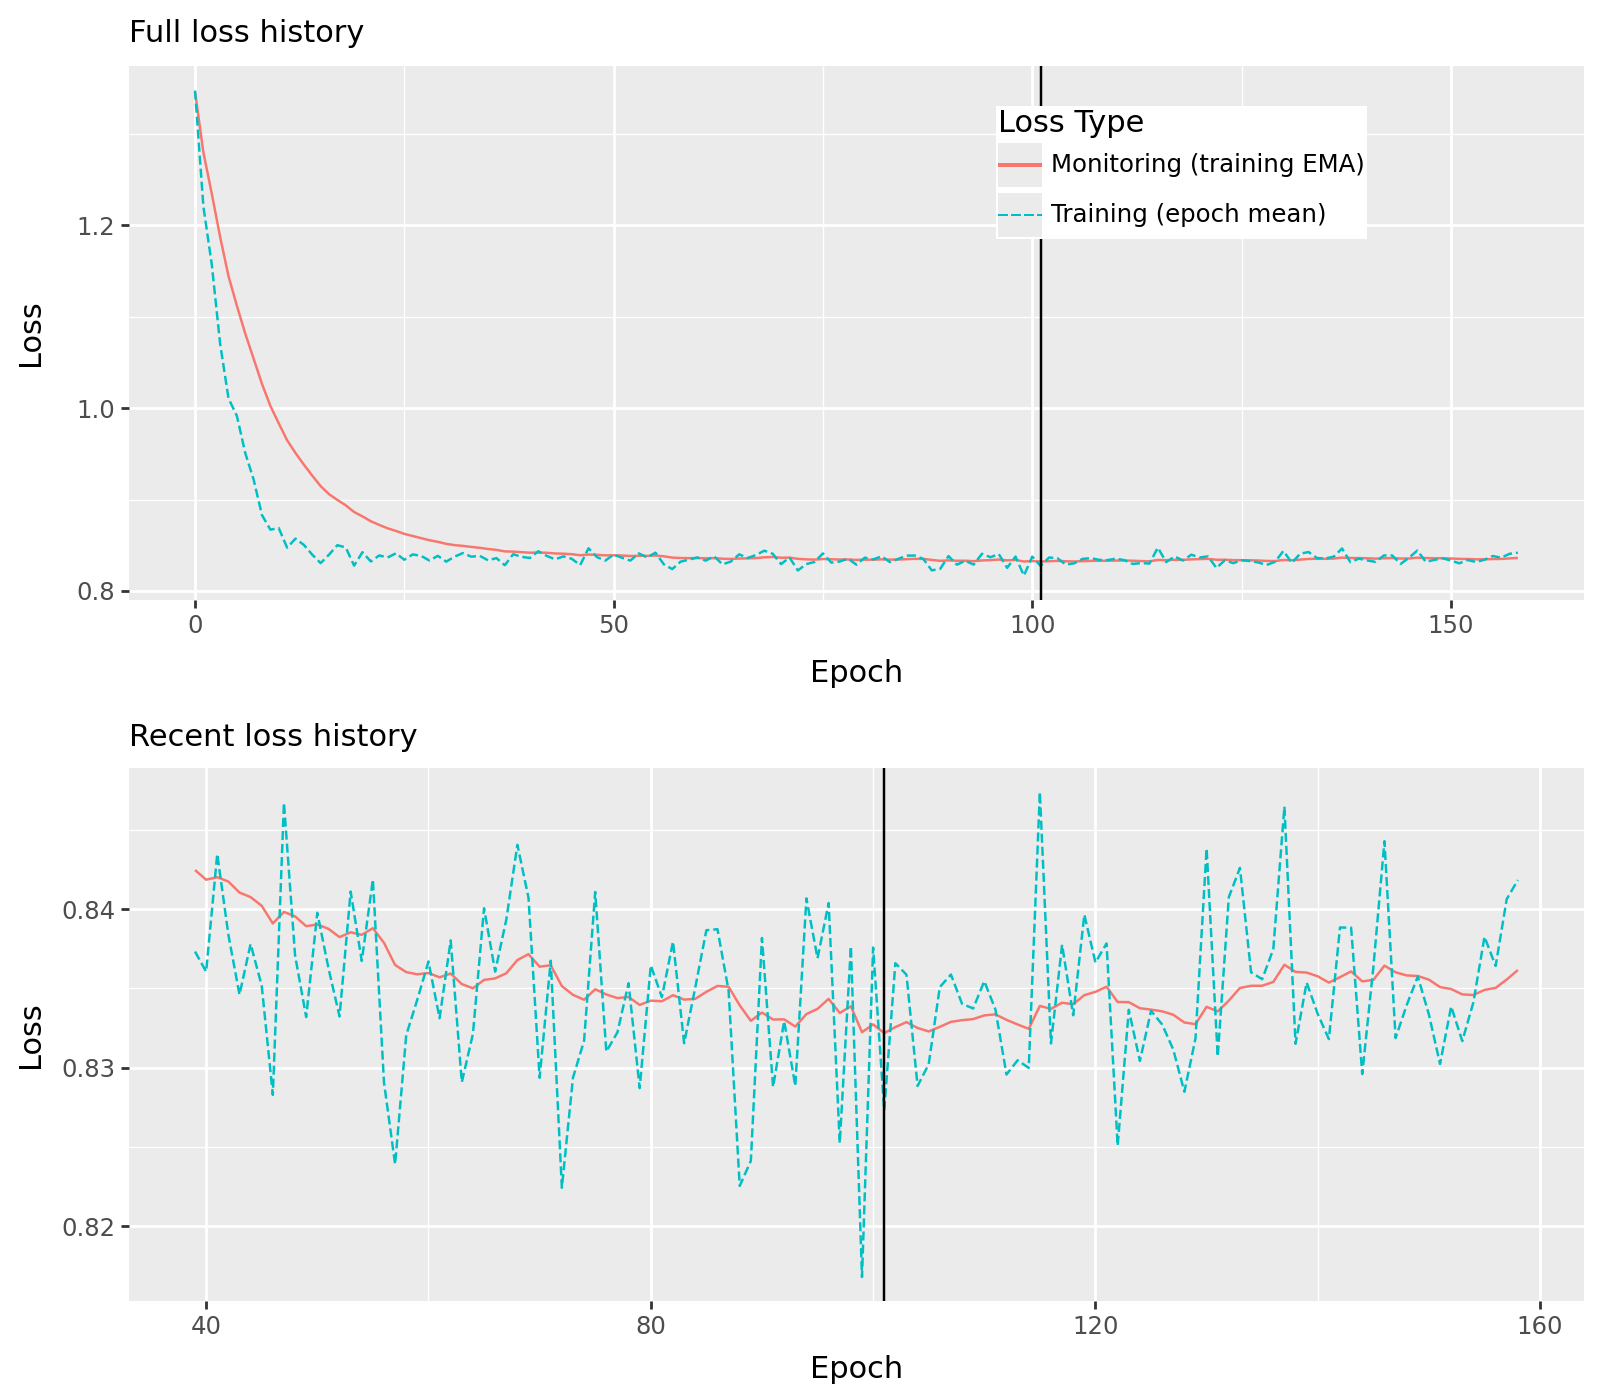

In [23]:
result.plot_loss_overview()

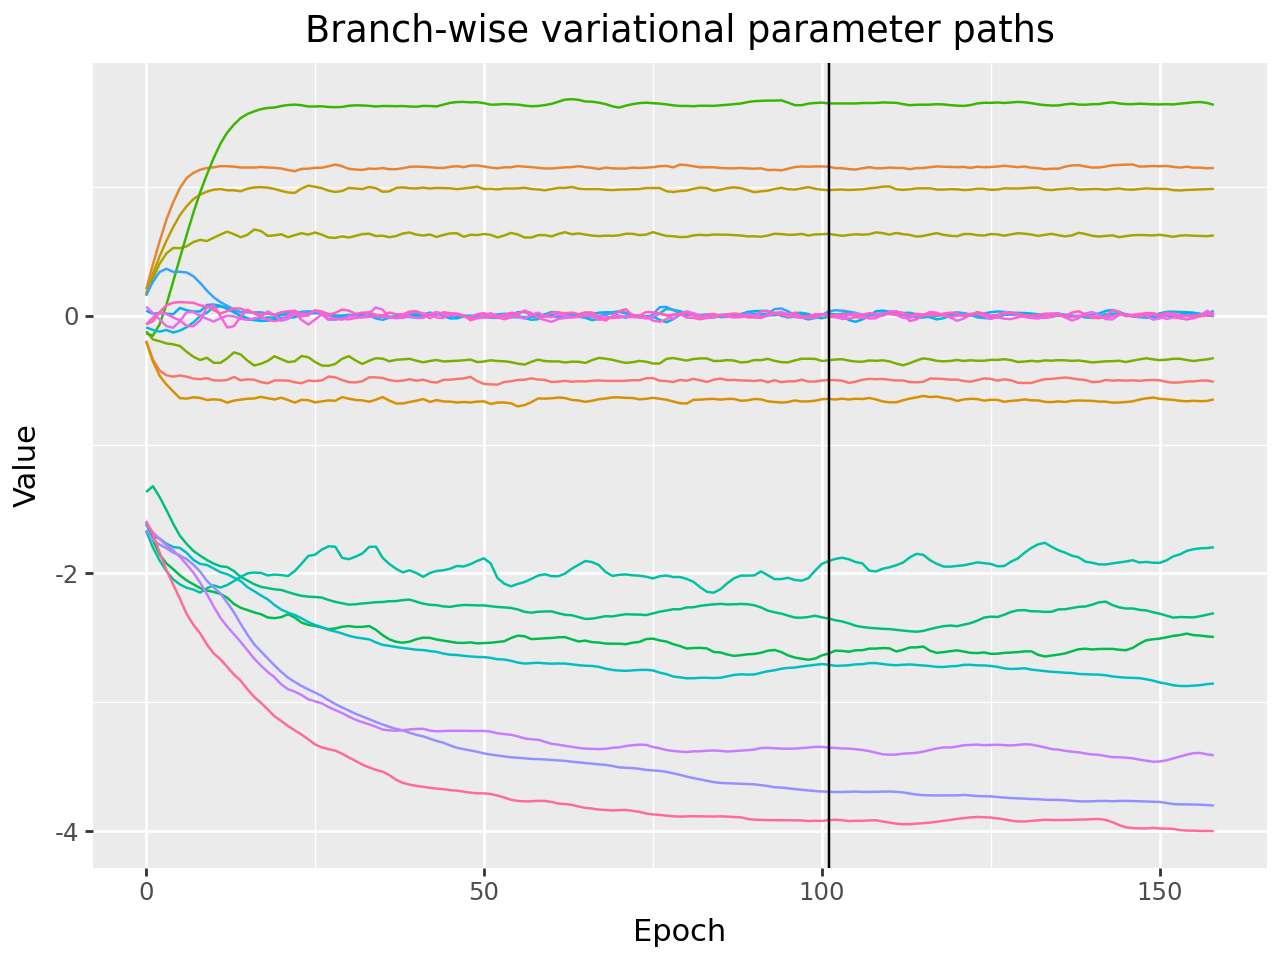

In [24]:
result.plot_params(
    title="Branch-wise variational parameter paths",
    subset=list(loss.q.parameters),
) + p9.theme(legend_position="none")

## Check held-out predictions

Use {meth}`model.predict <liesel.model.Model.predict>` to evaluate both branches on the test data. Convert logits to probabilities before averaging over posterior draws (axis 0). Compare the predicted means with held-out responses using Brier score and root mean squared error.

In [25]:
predictions = model.predict(
    posterior,
    predict=["zero_logit", "mean_pos"],
    newdata=split.test,
)
zero_prob_hat = np.asarray(jax.nn.sigmoid(predictions["zero_logit"]).mean(axis=0))
positive_mean_hat = np.asarray(predictions["mean_pos"].mean(axis=0))

zero_test = np.asarray(split.test["zero_count"])
y_pos_test = np.asarray(split.test["y_pos"])
zero_brier = np.mean((zero_prob_hat - zero_test) ** 2)
positive_rmse = np.sqrt(np.mean((positive_mean_hat - y_pos_test) ** 2))

In [26]:
pd.DataFrame(
    {
        "min_monitor_epoch": [result.min_monitor_epoch],
        "n_epochs": [result.n_epochs],
        "zero_branch_brier": [zero_brier],
        "positive_branch_rmse": [positive_rmse],
    }
)

,min_monitor_epoch,n_epochs,zero_branch_brier,positive_branch_rmse
0,101,159,0.178,1.094


Plot calibration for zero probabilities and fitted versus observed positive responses:

In [27]:
zero_checks = pd.DataFrame({"fitted": zero_prob_hat, "observed": zero_test})
calibration = zero_checks.groupby(
    pd.cut(zero_checks["fitted"], bins=7), observed=True
).agg(fitted=("fitted", "mean"), observed=("observed", "mean"))
calibration_plot = (
    p9.ggplot(calibration, p9.aes("fitted", "observed"))
    + p9.geom_abline(intercept=0, slope=1, linetype="dashed")
    + p9.geom_line()
    + p9.geom_point(size=2)
    + p9.coord_cartesian(xlim=(0, 1), ylim=(0, 1))
    + p9.labs(x="Fitted zero probability", y="Observed zero rate")
)
positive_checks = pd.DataFrame({"fitted": positive_mean_hat, "observed": y_pos_test})
positive_check_plot = (
    p9.ggplot(positive_checks, p9.aes("fitted", "observed"))
    + p9.geom_point(alpha=0.45, size=1.4)
    + p9.geom_abline(intercept=0, slope=1, linetype="dashed")
    + p9.labs(x="Fitted positive mean", y="Observed positive response")
)

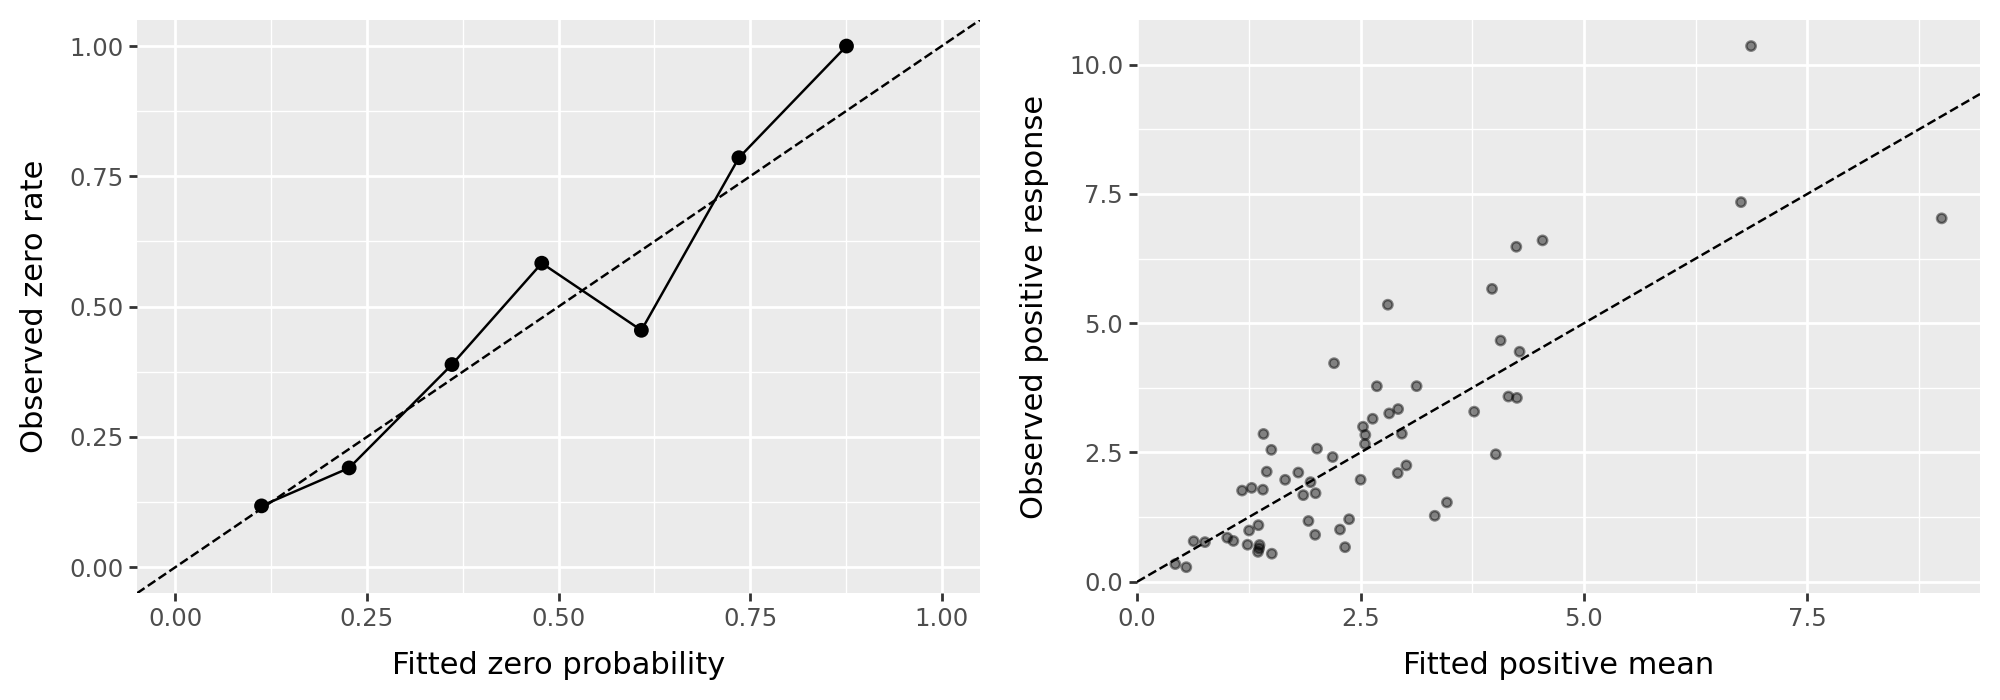

In [28]:
(calibration_plot | positive_check_plot) & p9.theme(figure_size=(10, 3.5))